# 04 Multi-Criteria Integration — Weighted Linear Combination

**PA1 ZHAW IUNR** | Bächler, Haag, Reichlin | Betreuer: Patrick Laube

Verschneidet die 10 normalisierten Eignungsfaktoren (F01–F10) aus Notebook 03 mittels gewichteter linearer Kombination (WLC).

**Input:**
```
data/processed/criteria/f01_globalstrahlung.tif  … f10_sichtbarkeit.tif
data/processed/constraints/constraint_mask_s2.tif
```

**Output:**
```
outputs/suitability_wlc.tif          (kontinuierlich 0–1)
outputs/suitability_classes.tif       (5 Klassen)
outputs/figures/suitability_map.png
outputs/tables/suitability_stats.csv
```

## 1. Setup & Imports

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import warnings
warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
OUT  = Path("../outputs")
for d in [OUT, OUT / "figures", OUT / "tables"]:
    d.mkdir(parents=True, exist_ok=True)

NODATA = -9999.0

## 2. Gewichtungen

Hier die AHP-Gewichte anpassen. **Summe muss 1.0 ergeben.**

| ID | Kriterium | Quelle |
|---|---|---|
| F01 | Globalstrahlung Jahressumme | Kahl et al. (2019) |
| F02 | Wintereinstrahlung Okt–März | Art. 71a EnG, Frischholz et al. (2024) |
| F03 | Hangneigung (Optimum 20–30°) | Swissolar (2025) 4.1.1 |
| F04 | Exposition (Südabweichung) | Kahl et al. (2019) |
| F05 | Höhenlage (1800–2500 m) | Kahl et al. (2019) |
| F06 | Schneebedeckung (SCD) | Kahl et al. (2019) |
| F07 | Distanz Netzanschluss | Swissolar (2025) 4.1.6 |
| F08 | Distanz Strasse | Dujardin et al. (2022) |
| F09 | Nähe Infrastruktur | Swissolar (2025) 4.1.6 + 4.2.1 |
| F10 | Sichtbarkeit | Swissolar (2025) 4.2.1 |

In [11]:
# ╔══════════════════════════════════════════════════════════╗
# ║  GEWICHTUNGEN HIER ANPASSEN  (Summe muss = 1.0 sein)   ║
# ╚══════════════════════════════════════════════════════════╝

WEIGHTS = {
    "f01_globalstrahlung":     0.25,   # Globalstrahlung Jahressumme
    "f02_wintereinstrahlung":  0.10,   # Wintereinstrahlung Okt–März
    "f03_hangneigung":         0.12,   # Hangneigung (Optimum 20–30°)
    "f04_exposition":          0.12,   # Exposition (Südabweichung)
    "f05_hoehenlage":          0.10,   # Höhenlage (1800–2500 m)
    "f06_schneebedeckung":     0.06,   # Schneebedeckung (SCD)
    "f07_netzanschluss":       0.08,   # Distanz Netzanschluss
    "f08_strasse":             0.07,   # Distanz Strasse
    "f09_infrastruktur":       0.05,   # Nähe Infrastruktur
    "f10_sichtbarkeit":        0.05,   # Sichtbarkeit
}

# ╔══════════════════════════════════════════════════════════╗
# ║  EIGNUNGSKLASSEN  (Schwellenwerte anpassbar)            ║
# ╚══════════════════════════════════════════════════════════╝

CLASSES = {
    1: (0.0, 0.2, "Ungeeignet"),
    2: (0.2, 0.4, "Gering geeignet"),
    3: (0.4, 0.6, "Mässig geeignet"),
    4: (0.6, 0.8, "Gut geeignet"),
    5: (0.8, 1.0, "Sehr gut geeignet"),
}

# Validierung
w_sum = sum(WEIGHTS.values())
print(f"Summe Gewichte: {w_sum:.4f}")
assert abs(w_sum - 1.0) < 1e-6, f"Gewichte summieren nicht zu 1.0 ({w_sum:.6f})!"
print("✓ Gewichte OK")
print()
for name, w in WEIGHTS.items():
    bar = '█' * int(w * 50)
    print(f"  {name:30s} {w:.2f}  {bar}")

Summe Gewichte: 1.0000
✓ Gewichte OK

  f01_globalstrahlung            0.25  ████████████
  f02_wintereinstrahlung         0.10  █████
  f03_hangneigung                0.12  ██████
  f04_exposition                 0.12  ██████
  f05_hoehenlage                 0.10  █████
  f06_schneebedeckung            0.06  ███
  f07_netzanschluss              0.08  ████
  f08_strasse                    0.07  ███
  f09_infrastruktur              0.05  ██
  f10_sichtbarkeit               0.05  ██


## 3. Funktionen

In [12]:
def load_criteria(criteria_dir, weight_dict, nodata):
    """Lädt alle Kriterien-Raster und gibt Arrays + Profile zurück."""
    rasters = {}
    profile = None
    for name in weight_dict:
        path = criteria_dir / f"{name}.tif"
        if not path.exists():
            raise FileNotFoundError(f"Kriterium fehlt: {path}")
        with rasterio.open(path) as src:
            data = src.read(1)
            if profile is None:
                profile = src.profile.copy()
        rasters[name] = data
        v = data[data != nodata]
        print(f"  {name:30s}  min={v.min():.3f}  max={v.max():.3f}  mean={v.mean():.3f}")
        if v.min() < -0.01 or v.max() > 1.01:
            print(f"    ⚠ Werte ausserhalb [0, 1]!")
    return rasters, profile


def compute_wlc(rasters, weight_dict, valid_mask, nodata):
    """Berechnet die gewichtete Linearkombination (WLC)."""
    h, w = valid_mask.shape
    result = np.full((h, w), nodata, dtype=np.float32)
    weighted_sum = np.zeros((h, w), dtype=np.float64)
    all_valid = valid_mask.copy()

    for name, weight in weight_dict.items():
        data = rasters[name]
        all_valid &= (data != nodata)
        weighted_sum += weight * np.where(data != nodata, data, 0)

    result[all_valid] = weighted_sum[all_valid].astype(np.float32)
    return result


def classify_suitability(suitability, class_dict, valid_mask, nodata):
    """Teilt kontinuierlichen Score in diskrete Eignungsklassen ein."""
    classified = np.full(suitability.shape, 0, dtype=np.uint8)
    m = valid_mask & (suitability != nodata)
    for cls_id, (lo, hi, _) in class_dict.items():
        in_class = m & (suitability >= lo) & (suitability < hi)
        classified[in_class] = cls_id
    # Obergrenze 1.0 in höchste Klasse
    max_cls = max(class_dict.keys())
    classified[m & (suitability >= 1.0)] = max_cls
    return classified


def compute_statistics(suitability, classified, class_dict, valid_mask, nodata, res):
    """Berechnet Flächenstatistik pro Eignungsklasse."""
    m = valid_mask & (suitability != nodata)
    pixel_area_km2 = (res * res) / 1e6
    rows = []
    for cls_id, (lo, hi, label) in class_dict.items():
        mask_cls = m & (classified == cls_id)
        n = mask_cls.sum()
        vals = suitability[mask_cls]
        rows.append({
            "Klasse": cls_id,
            "Label": label,
            "Bereich": f"{lo:.1f}–{hi:.1f}",
            "Pixel": n,
            "Fläche_km2": round(n * pixel_area_km2, 2),
            "Anteil_%": round(100 * n / m.sum(), 1) if m.sum() > 0 else 0,
            "Mean": round(vals.mean(), 3) if n > 0 else None,
            "Std": round(vals.std(), 3) if n > 0 else None,
        })
    # Gesamtzeile
    total_n = m.sum()
    rows.append({
        "Klasse": "",
        "Label": "TOTAL",
        "Bereich": "0.0–1.0",
        "Pixel": total_n,
        "Fläche_km2": round(total_n * pixel_area_km2, 2),
        "Anteil_%": 100.0,
        "Mean": round(suitability[m].mean(), 3),
        "Std": round(suitability[m].std(), 3),
    })
    return pd.DataFrame(rows)


def save_raster(data, path, profile, dtype="float32", nodata_val=None):
    """Speichert ein Raster als GeoTIFF."""
    p = profile.copy()
    p.update(dtype=dtype, count=1, compress="deflate")
    if nodata_val is not None:
        p.update(nodata=nodata_val)
    with rasterio.open(path, "w", **p) as dst:
        dst.write(data.astype(dtype), 1)
    print(f"  ✓ {path}")


def plot_suitability(suitability, classified, class_dict, valid_mask, nodata, transform, out_path):
    """Erstellt Karte mit Eignungsklassen."""
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Links: Kontinuierlicher Score (cividis: farbenblind-sicher)
    display = np.where(valid_mask & (suitability != nodata), suitability, np.nan)
    im = axes[0].imshow(display, cmap="cividis", vmin=0, vmax=1)
    axes[0].set_title("Eignung (kontinuierlich 0–1)", fontsize=13)
    plt.colorbar(im, ax=axes[0], label="Eignungswert", shrink=0.7)
    axes[0].set_axis_off()

    # Rechts: Klassen (Palette: farbenblind-sicher, nach Crameri et al.)
    colors = ["#313695", "#74add1", "#ffffbf", "#f46d43", "#a50026"]
    cmap = ListedColormap(colors)
    bounds = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
    norm = BoundaryNorm(bounds, cmap.N)
    display_cls = np.where(valid_mask & (classified > 0), classified.astype(float), np.nan)
    im2 = axes[1].imshow(display_cls, cmap=cmap, norm=norm)
    axes[1].set_title("Eignungsklassen", fontsize=13)
    cbar = plt.colorbar(im2, ax=axes[1], ticks=[1, 2, 3, 4, 5], shrink=0.7)
    cbar.ax.set_yticklabels([v[2] for v in class_dict.values()])
    axes[1].set_axis_off()

    plt.tight_layout()
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"  ✓ {out_path}")

## 4. Constraint-Maske laden

In [13]:
mask_path = PROC / "constraints/constraint_mask_s2.tif"
with rasterio.open(mask_path) as src:
    constraint_mask = src.read(1)
    transform = src.transform

with rasterio.open(PROC / "dem/dem_gr_25m.tif") as src:
    dem = src.read(1)

valid = (dem != NODATA) & (constraint_mask == 1)
print(f"Geeignete Pixel (Constraint-Maske): {valid.sum():,} ({valid.sum() * 25 * 25 / 1e6:.0f} km²)")

Geeignete Pixel (Constraint-Maske): 876,268 (548 km²)


## 5. Kriterien laden & prüfen

In [14]:
print("=== Lade 10 Eignungskriterien ===\n")
rasters, ref_profile = load_criteria(PROC / "criteria", WEIGHTS, NODATA)
print(f"\n✓ Alle {len(rasters)} Kriterien geladen")

=== Lade 10 Eignungskriterien ===

  f01_globalstrahlung             min=0.000  max=1.000  mean=0.844
  f02_wintereinstrahlung          min=0.000  max=1.000  mean=0.741
  f03_hangneigung                 min=0.000  max=1.000  mean=0.872
  f04_exposition                  min=0.667  max=1.000  mean=0.832
  f05_hoehenlage                  min=0.000  max=1.000  mean=0.874
  f06_schneebedeckung             min=0.000  max=1.000  mean=0.727
  f07_netzanschluss               min=0.000  max=1.000  mean=0.575
  f08_strasse                     min=0.000  max=1.000  mean=0.715
  f09_infrastruktur               min=0.000  max=1.000  mean=0.509
  f10_sichtbarkeit                min=0.038  max=1.000  mean=0.418

✓ Alle 10 Kriterien geladen


## 6. WLC berechnen

In [15]:
print("=== WLC: Gewichtete Linearkombination ===\n")
suitability = compute_wlc(rasters, WEIGHTS, valid, NODATA)

v = suitability[valid & (suitability != NODATA)]
print(f"  Gültige Pixel:  {v.size:,}")
print(f"  Wertebereich:   {v.min():.4f} – {v.max():.4f}")
print(f"  Mittelwert:     {v.mean():.4f}")
print(f"  Median:         {np.median(v):.4f}")
print(f"  Std:            {v.std():.4f}")

=== WLC: Gewichtete Linearkombination ===

  Gültige Pixel:  876,268
  Wertebereich:   0.3746 – 0.9285
  Mittelwert:     0.7631
  Median:         0.7690
  Std:            0.0556


## 7. Eignungsklassen

In [16]:
print("=== Klassifikation ===\n")
classified = classify_suitability(suitability, CLASSES, valid, NODATA)

stats = compute_statistics(suitability, classified, CLASSES, valid, NODATA, res=25)
print(stats.to_string(index=False))

=== Klassifikation ===

Klasse             Label Bereich  Pixel  Fläche_km2  Anteil_%  Mean   Std
     1        Ungeeignet 0.0–0.2      0        0.00       0.0   NaN   NaN
     2   Gering geeignet 0.2–0.4      3        0.00       0.0 0.384 0.010
     3   Mässig geeignet 0.4–0.6   5676        3.55       0.6 0.573 0.027
     4      Gut geeignet 0.6–0.8 633104      395.69      72.3 0.741 0.043
     5 Sehr gut geeignet 0.8–1.0 237485      148.43      27.1 0.826 0.020
                   TOTAL 0.0–1.0 876268      547.67     100.0 0.763 0.056


## 8. Karte

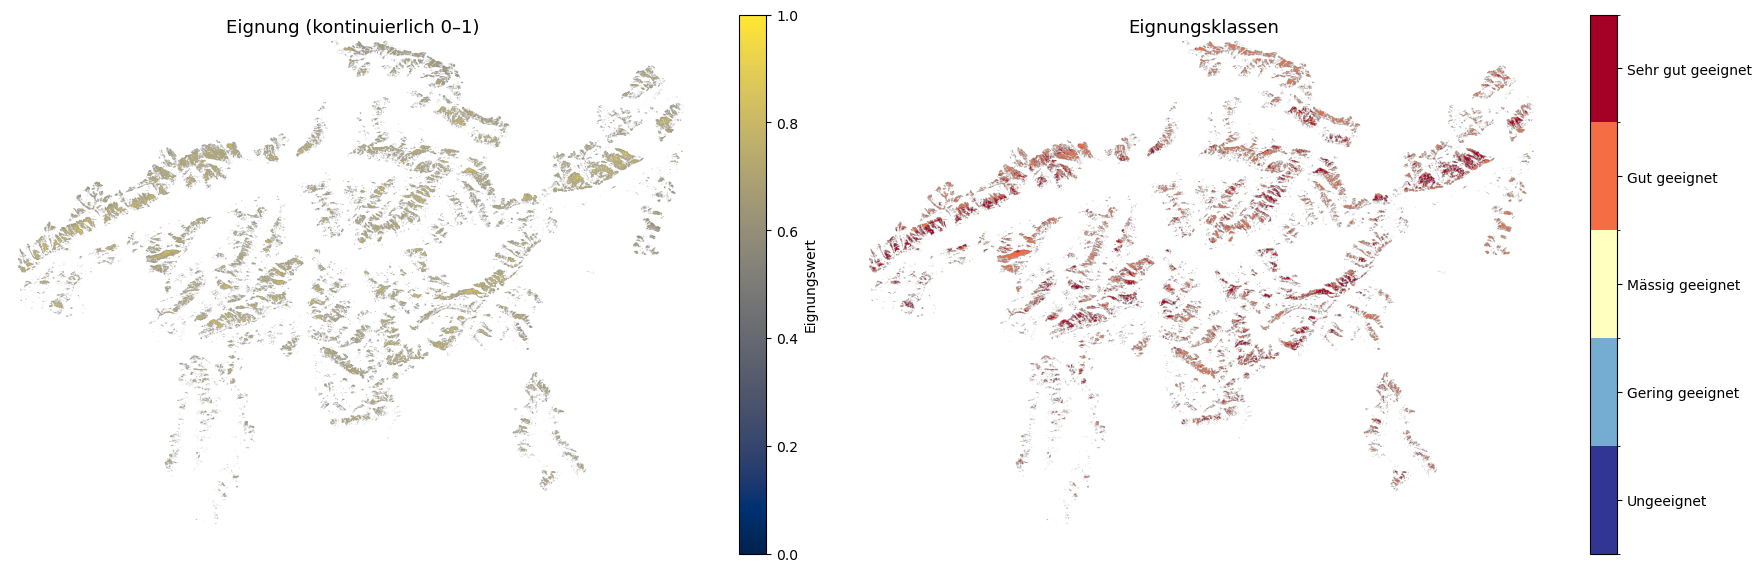

  ✓ ..\outputs\figures\suitability_map.png


In [17]:
plot_suitability(
    suitability, classified, CLASSES,
    valid, NODATA, transform,
    OUT / "figures/suitability_map.png"
)

## 9. Outputs speichern

In [18]:
print("=== Speichere Outputs ===\n")

save_raster(suitability, OUT / "suitability_wlc.tif", ref_profile,
            dtype="float32", nodata_val=NODATA)

save_raster(classified, OUT / "suitability_classes.tif", ref_profile,
            dtype="uint8", nodata_val=0)

stats.to_csv(OUT / "tables/suitability_stats.csv", index=False)
print(f"  ✓ {OUT / 'tables/suitability_stats.csv'}")

print("\n=== Fertig ===")

=== Speichere Outputs ===

  ✓ ..\outputs\suitability_wlc.tif
  ✓ ..\outputs\suitability_classes.tif
  ✓ ..\outputs\tables\suitability_stats.csv

=== Fertig ===


## Nächster Schritt

Die Eignungskarte (`suitability_wlc.tif`) und Klassen (`suitability_classes.tif`) können mit einem politischen Akzeptanz-Layer kombiniert werden.

**→ Weiter mit:** Sensitivity-Analyse / Validierung